In [193]:
import glob
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [194]:
PACKAGE_USED = 0  # 0 = sklearn; 1 = sktime; 2 = aeon

In [195]:
APPROACH = "svm"

In [196]:
CHANNEL_CONFIG = "g-a"

In [197]:
TRAIN_DIR = [
    R"dataset3"
]

In [198]:
TEST_DIR = [
    R"dataset3"
]

# Build DataFrame

In [199]:
def build_df(dirs):
    """
    dirs: list of directory paths containing CSV files
    """
    all_csv_files = []

    for _DIR in dirs:
        file_pattern = os.path.join(_DIR, "*.csv")
        csv_files = glob.glob(file_pattern)
        print(f"{_DIR} -> {len(csv_files)} CSV files found")
        all_csv_files.extend(csv_files)

    print(f"A total of {len(all_csv_files)} CSV files were used in constructing this DataFrame.")

    if not all_csv_files:
        raise ValueError("No CSV files found in the provided directories.")

    df = pd.concat((pd.read_csv(f) for f in all_csv_files), ignore_index=True)
    return df

In [200]:
df_train = build_df(TRAIN_DIR)

dataset3 -> 90 CSV files found
A total of 90 CSV files were used in constructing this DataFrame.


In [201]:
df_test = build_df(TEST_DIR)

dataset3 -> 90 CSV files found
A total of 90 CSV files were used in constructing this DataFrame.


In [202]:
print(df_train.duplicated().sum())

0


In [203]:
print(df_test.duplicated().sum())

0


In [204]:
df_train.drop_duplicates(inplace=True)

In [205]:
df_test.drop_duplicates(inplace=True)

## Remove unneeded columns

In [206]:
match CHANNEL_CONFIG:
    case "gyro":
        df_train = df_train.filter(regex=r'^(gyro|motion)')
        df_test = df_test.filter(regex=r'^(gyro|motion)')
    case "accel":
        df_train = df_train.filter(regex=r'^(acc|motion)')
        df_test = df_test.filter(regex=r'^(acc|motion)')
    case "mag":
        df_train = df_train.filter(regex=r'^(mag|motion)')
        df_test = df_test.filter(regex=r'^(mag|motion)')
    case "ahrs":
        df_train = df_train.filter(regex=r'^(ahrs|motion)')
        df_test = df_test.filter(regex=r'^(ahrs|motion)')
    case "g-a":
        df_train = df_train.filter(regex=r'^(gyro|acc|motion)')
        df_test = df_test.filter(regex=r'^(gyro|acc|motion)')
    case "g-m":
        df_train = df_train.filter(regex=r'^(gyro|mag|motion)')
        df_test = df_test.filter(regex=r'^(gyro|mag|motion)')
    case "a-m":
        df_train = df_train.filter(regex=r'^(acc|mag|motion)')
        df_test = df_test.filter(regex=r'^(acc|mag|motion)')
    case "g-a-m":
        df_train = df_train.filter(regex=r'^(gyro|acc|mag|motion)')
        df_test = df_test.filter(regex=r'^(gyro|acc|mag|motion)')
    case _:
        pass

## Downsample: Split each 30-timestep sample into two 15-timestep samples

Original data is captured at **60 Hz** with 30 timesteps per sample (columns `{sensor}_{axis}_0` … `{sensor}_{axis}_29`).

We split each row into:
- **Even sample** (Dataset 1): timesteps 0, 2, 4, …, 28 → re-indexed as 0–14
- **Odd sample**  (Dataset 2): timesteps 1, 3, 5, …, 29 → re-indexed as 0–14

In [207]:
ORIGINAL_TIMESTEPS = 30 # Source 
NEW_TIMESTEPS = 15 # Output

In [208]:
def downsample_avg_pool(df: pd.DataFrame, original_timesteps: int = 30) -> pd.DataFrame:
    """
    Downsample by averaging adjacent timestamp pairs:
      new_t0 = (t0 + t1) / 2
      new_t1 = (t2 + t3) / 2
      ...
      new_t14 = (t28 + t29) / 2

    Result: same number of rows, half the timesteps.
    """
    import re
    pattern = re.compile(r'^(.+)_(\d+)$')
    prefixes, seen = [], set()
    for col in df.columns:
        m = pattern.match(col)
        if m:
            p = m.group(1)
            if p not in seen:
                prefixes.append(p)
                seen.add(p)

    new_df = pd.DataFrame()
    new_df["motion_type"] = df["motion_type"].values

    new_t = 0
    for t in range(0, original_timesteps, 2):
        for prefix in prefixes:
            col_a = f"{prefix}_{t}"
            col_b = f"{prefix}_{t + 1}"
            new_df[f"{prefix}_{new_t}"] = (df[col_a].values + df[col_b].values) / 2.0
        new_t += 1

    return new_df.reset_index(drop=True)

In [238]:
def split_60hz_to_30hz(df: pd.DataFrame, original_timesteps: int = 30) -> pd.DataFrame:
    print(df)
    pattern = re.compile(r'^(.+)_(\d+)$')
    prefixes = []
    seen = set()
    for col in df.columns:
        m = pattern.match(col)
        if m:
            prefix = m.group(1)
            if prefix not in seen:
                prefixes.append(prefix)
                seen.add(prefix)

    even_indices = list(range(0, original_timesteps, 2))   # [0, 2, 4, …, 28]
    odd_indices  = list(range(1, original_timesteps, 2))   # [1, 3, 5, …, 29]

    def build_row(row, timestep_indices):
        """Extract one downsampled row from a source row."""
        new_row = {"motion_type": row["motion_type"]}
        for prefix in prefixes:
            for new_t, old_t in enumerate(timestep_indices):
                new_row[f"{prefix}_{new_t}"] = row[f"{prefix}_{old_t}"]
        return new_row

    even_rows = [build_row(row, even_indices) for _, row in df.iterrows()]
    odd_rows  = [build_row(row, odd_indices)  for _, row in df.iterrows()]

    # Interleave: even sample from row i followed by odd sample from row i
    combined = []
    for e, o in zip(even_rows, odd_rows):
        combined.append(e)
        combined.append(o)

    return pd.DataFrame(combined).reset_index(drop=True)

In [210]:
print(f"df_train before split: {df_train.shape}")
df_train = downsample_avg_pool(df_train, original_timesteps=ORIGINAL_TIMESTEPS)
print(f"df_train after  split: {df_train.shape}  (expected 2× rows, {NEW_TIMESTEPS} timesteps)")

df_train before split: (8951, 181)
df_train after  split: (8951, 91)  (expected 2× rows, 15 timesteps)


In [ ]:
print(f"df_test before split: {df_test.shape}")
df_train = downsample_avg_pool(df_test, original_timesteps=ORIGINAL_TIMESTEPS)
print(f"df_test after  split: {df_test.shape}  (expected 2× rows, {NEW_TIMESTEPS} timesteps)")

df_test before split: (8951, 181)
df_test after  split: (8951, 181)  (expected 2× rows, 15 timesteps)


In [212]:
df_train.head()

,motion_type,gyro_x_0,gyro_y_0,gyro_z_0,acc_x_0,acc_y_0,acc_z_0,gyro_x_1,gyro_y_1,gyro_z_1,...,gyro_z_13,acc_x_13,acc_y_13,acc_z_13,gyro_x_14,gyro_y_14,gyro_z_14,acc_x_14,acc_y_14,acc_z_14
0,FAN,0.092538,0.079750,-4.035212,0.412662,2.488150,4.097744,-14.347275,-13.007856,-5.686838,...,-7.805350,5.717281,5.070306,4.779581,0.039800,1.231737,3.997556,-1.166025,-4.209975,-4.341000
1,FAN,-8.182763,-0.365131,0.415869,7.377475,3.678256,2.680713,-0.106762,0.113894,0.105644,...,-14.721981,1.888644,2.113787,3.021781,1.403294,2.416144,2.647506,-3.136500,-3.774975,-4.373550
2,FAN,-11.019800,-0.137500,0.145819,5.136875,1.471931,1.066056,-0.168475,-0.158094,0.145431,...,-8.095931,1.667150,-0.611587,-6.264038,0.343062,0.072412,-2.081369,-1.164525,-1.061025,-2.193975
3,FAN,-13.875331,-13.204057,-4.090144,-5.843206,-4.555244,-0.406200,-1.262475,-0.566600,-0.416588,...,-1.465538,3.296619,1.464925,-2.020919,0.393425,0.678850,0.354969,0.744000,-1.633950,-2.402025
4,FAN,-6.742519,-0.960919,-0.099069,-6.348144,-2.427150,-0.174781,0.374231,0.939906,3.982931,...,5.491156,3.487744,1.983431,3.489587,0.897269,0.411069,0.780806,-1.810950,-2.048025,-1.640025


In [213]:
df_test.head()

,gyro_x_0,gyro_y_0,gyro_z_0,acc_x_0,acc_y_0,acc_z_0,gyro_x_1,gyro_y_1,gyro_z_1,acc_x_1,...,acc_x_28,acc_y_28,acc_z_28,gyro_x_29,gyro_y_29,gyro_z_29,acc_x_29,acc_y_29,acc_z_29,motion_type
0,-1.773337,-4.313787,-18.885487,4.131325,6.713300,9.199437,1.958413,4.473288,10.815063,-3.30600,...,-1.94505,-0.53400,0.72900,-0.93405,-0.16305,-0.24705,-0.387000,-7.885951,-9.411000,FAN
1,-16.458338,-3.044525,-1.269950,13.055900,5.561462,3.389375,0.092813,2.314262,2.101687,1.69905,...,0.21195,0.46305,0.64995,-0.57000,-0.47700,-0.42705,-6.484951,-8.013000,-9.397051,FAN
2,-26.429424,-2.282638,-1.218663,10.215700,1.709813,0.993163,4.389825,2.007638,1.510300,0.05805,...,1.38495,2.15400,1.21500,-0.26400,-0.75195,-0.40005,-3.714000,-4.276050,-5.602950,FAN
3,-30.871225,-29.799826,-16.290174,-13.684412,-11.532537,-2.935350,3.120563,3.391712,8.109887,1.99800,...,0.97095,0.97305,1.56300,-0.27795,0.28905,0.33195,0.517050,-4.240950,-6.367050,FAN
4,-13.943050,-2.863437,-0.675812,-14.005338,-6.146250,-1.756562,0.458012,0.941600,0.477675,1.30905,...,0.88005,1.76100,2.21595,0.45900,0.15705,-0.37095,-4.501950,-5.857050,-5.496000,FAN


<Axes: xlabel='motion_type', ylabel='count'>

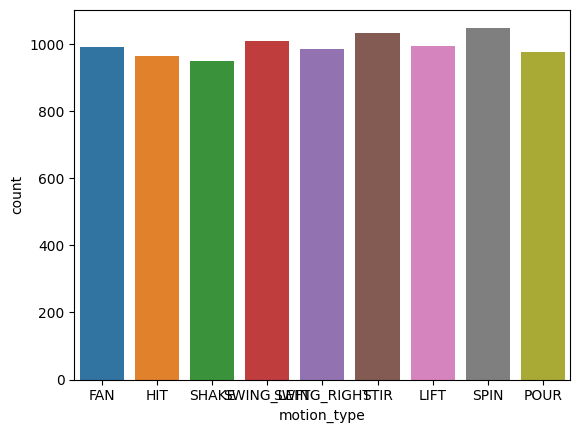

In [214]:
sns.countplot(df_train, x="motion_type", hue="motion_type")

In [215]:
len(df_train)

8951

<Axes: xlabel='motion_type', ylabel='count'>

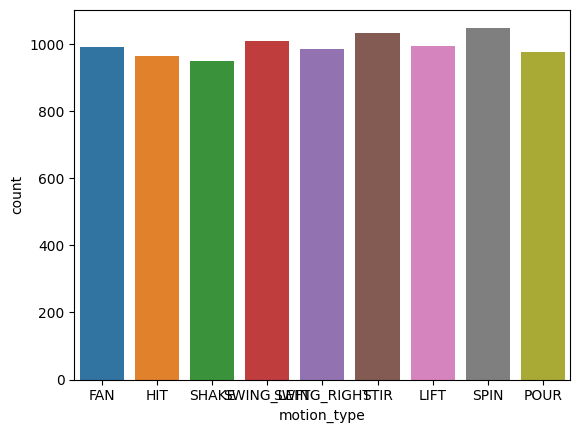

In [216]:
sns.countplot(df_test, x="motion_type", hue="motion_type")

In [217]:
len(df_test)

8951

## Get X and y

In [218]:
from sklearn.preprocessing import LabelEncoder

In [219]:
def get_X_and_y(df: pd.DataFrame, package_used: int, n_timesteps: int = NEW_TIMESTEPS) -> tuple[np.array, np.array]:
    if package_used == 0:  # sklearn
        X = df.drop(columns=["motion_type"]).values
        y = df["motion_type"].values
        return X.astype("float32"), y
    
    elif package_used == 1:  # sktime
        X_df = df.drop(columns=["motion_type"])
        y = df["motion_type"].values
        
        channels = []
        match CHANNEL_CONFIG:
            case "accel":
                channels = ["accel_x", "accel_y", "accel_z"]
            case "gyro":
                channels = ["gyro_x", "gyro_y", "gyro_z"]
            case "mag":
                channels = ["mag_x", "mag_y", "mag_z"]
            case "ahrs":
                channels = ["ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"]
            case "g-a":
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z"]
            case "g-m":
                channels = ["gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z"]
            case "a-m":
                channels = ["accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"]
            case "g-a-m":
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"]
            case _:
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z", "ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"]
        n_channels = len(channels)

        X = np.zeros((len(df), n_channels, n_timesteps))

        for t in range(n_timesteps):
            for c, channel in enumerate(channels):
                col_name = f"{channel}_{t}"
                X[:, c, t] = X_df[col_name].values
                
        return X.astype("float32"), y

    else:  # aeon
        y = df["motion_type"].values

        channels = {
            "accel": ["accel_x", "accel_y", "accel_z"],
            "gyro": ["gyro_x", "gyro_y", "gyro_z"],
            "mag": ["mag_x", "mag_y", "mag_z"],
            "ahrs": ["ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"],
            "g-a": ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z"],
            "g-m": ["gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z"],
            "a-m": ["accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"],
            "g-a-m": ["gyro_x", "gyro_y", "gyro_z",
                    "accel_x", "accel_y", "accel_z",
                    "mag_x", "mag_y", "mag_z"],
        }.get(CHANNEL_CONFIG, [
            "gyro_x","gyro_y","gyro_z",
            "accel_x","accel_y","accel_z",
            "mag_x","mag_y","mag_z",
            "ahrs_x","ahrs_y","ahrs_z","ahrs_w"
        ])

        n_channels = len(channels)
        X = np.zeros((len(df), n_channels, n_timesteps), dtype="float32")

        for t in range(n_timesteps):
            for c, ch in enumerate(channels):
                X[:, c, t] = df[f"{ch}_{t}"].values

        return X.astype("float32"), y

In [220]:
X_train, y_train = get_X_and_y(df_train, PACKAGE_USED)
X_test, y_test = get_X_and_y(df_test, PACKAGE_USED)

In [221]:
X_train.shape

(8951, 90)

In [222]:
y_train

array(['FAN', 'FAN', 'FAN', ..., 'LIFT', 'LIFT', 'LIFT'],
      shape=(8951,), dtype=object)

In [223]:
mapping = {'HIT': 0, 'SHAKE': 1, 'SWING_LEFT': 2, 'SWING_RIGHT': 3, 'FAN': 4, 'IDLE': 5, 'STIR': 6, 'LIFT': 7, 'SPIN': 8, 'POUR': 9}
y_train = np.vectorize(mapping.get)(y_train)
y_test = np.vectorize(mapping.get)(y_test)

In [224]:
unk_train = set(y_train) - set(mapping.keys())
print(f"Unknown labels in y_train: {unk_train}")

Unknown labels in y_train: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}


In [225]:
# from sktime.classification.kernel_based import RocketClassifier
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
# from sktime.classification.deep_learning import InceptionTimeClassifier
from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from xgboost import XGBClassifier
from aeon.classification.deep_learning import LITETimeClassifier

In [226]:
if PACKAGE_USED == 0:
    if APPROACH.lower() == "svm":
        clf_minirocket = SVC()
    elif APPROACH.lower() == "rf":
        clf_minirocket = RandomForestClassifier()
    elif APPROACH.lower() == "softmax":
        clf_minirocket = LogisticRegression(solver = "saga", max_iter=1000)

In [227]:
if PACKAGE_USED == 1:
    if APPROACH.lower() == "knn":
        clf_minirocket = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw")
    elif APPROACH.lower() == "minirocket":
        clf_minirocket = make_pipeline(
            MiniRocketMultivariate(random_state=42),
            RidgeClassifier(alpha=1.0)
        )

In [228]:
if PACKAGE_USED == 2:
    if APPROACH.lower() == "litemvtime":
        clf_minirocket = LITETimeClassifier(use_litemv=True)

In [229]:
clf_minirocket.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [230]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [231]:
y_pred_train = clf_minirocket.predict(X_train)

In [232]:
print(accuracy_score(y_train, y_pred_train))
print(precision_score(y_train, y_pred_train, average="weighted"))
print(recall_score(y_train, y_pred_train, average="weighted"))
print(f1_score(y_train, y_pred_train, average="weighted"))

0.9919562060105016
0.9920427249497935
0.9919562060105016
0.9919744975251987


In [241]:
y_pred_test = clf_minirocket.predict(X_train)

In [242]:
print(accuracy_score(y_test, y_pred_test))
print(precision_score(y_test, y_pred_test, average="weighted", zero_division=0))
print(recall_score(y_test, y_pred_test, average="weighted", zero_division=0))
print(f1_score(y_test, y_pred_test, average="weighted", zero_division=0))

0.9919562060105016
0.9920427249497935
0.9919562060105016
0.9919744975251987


In [243]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

[[ 963    0    0    0    0    0    0    2    0]
 [   0  946    0    0    0    0    1    1    2]
 [   1    0 1002    2    0    0    3    0    0]
 [   0    0    1  980    0    0    3    0    0]
 [   1    0    0    0  980    0    6    5    0]
 [   0    0    0    0    0 1025    8    0    0]
 [   0    0    0    0    3    2  985    3    0]
 [   3    0    0    1    3    0    5 1037    0]
 [   0    0    1    3    3    0    7    2  961]]


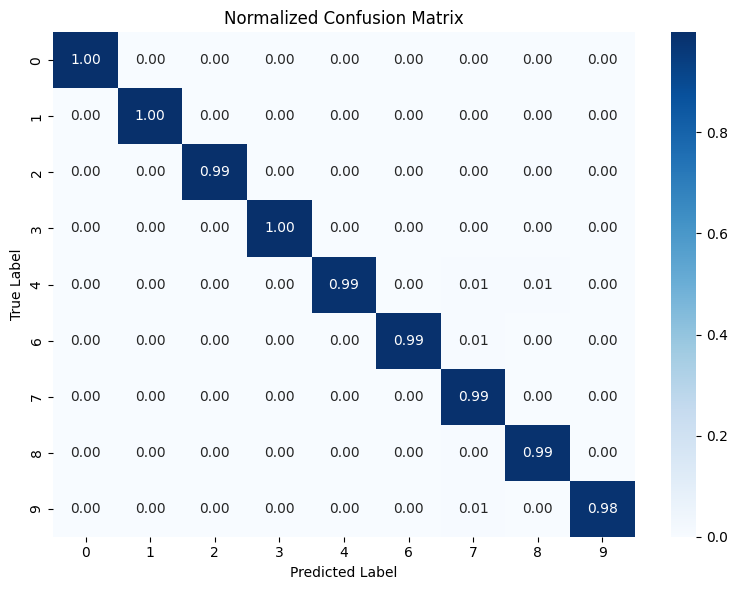

In [244]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_test)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

class_names = le.classes_.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(f"cmat_{APPROACH}.png")
plt.show()

In [245]:
from sklearn.metrics import classification_report

In [246]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       965
           1       1.00      1.00      1.00       950
           2       1.00      0.99      1.00      1008
           3       0.99      1.00      0.99       984
           4       0.99      0.99      0.99       992
           6       1.00      0.99      1.00      1033
           7       0.97      0.99      0.98       993
           8       0.99      0.99      0.99      1049
           9       1.00      0.98      0.99       977

    accuracy                           0.99      8951
   macro avg       0.99      0.99      0.99      8951
weighted avg       0.99      0.99      0.99      8951



In [247]:
from time import perf_counter

In [248]:
t0 = perf_counter()
a = clf_minirocket.predict(X_train[0:1])
t1 = perf_counter()

In [249]:
print(f"{t1 - t0} seconds taken to perform a single inference!")

0.0029328000091481954 seconds taken to perform a single inference!


In [250]:
from skl2onnx import to_onnx

if PACKAGE_USED == 0:
    onx = to_onnx(clf_minirocket, X_train[:1])
    with open(f"clf_{APPROACH}.onnx", "wb") as f:
        f.write(onx.SerializeToString())

In [251]:
from joblib import dump

dump(clf_minirocket, f"clf_{APPROACH}.joblib")

['clf_svm.joblib']

In [252]:
# clf_minirocket.predict(X_train[0:1])

In [253]:
# print(repr(X_train[0:1]))